# Final Report - Data Science

**Important**: this report may be written in either **Portuguese or English**. However, the selected language must be used consistently throughout the entire report. Mixing Portuguese and English is not allowed.

## Bachelor's Degree in Computer Science / PUCPR (2026-2)

**Prof. Rayson Laroca**

`Luiz Henrique Matoso` - `luiz.matoso@pucpr.edu.br`

# Import the libs you need

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data

Below, load the data using pandas and perform all necessary data cleaning to ensure that the data types are correct for further analysis.

In [2]:
df = pd.read_csv("../data/PhiUSIIL_Phishing_URL_Dataset.csv")

display(df.head())

print("Shape:", df.shape)

df.info()

display(df.describe())

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


Shape: (235795, 56)
<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasOb

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [3]:
# Check for missing values
missing_values = df.isnull().sum().sum()
print(f"Missing values: {missing_values}")

# Check for duplicated rows
duplicated_rows = df.duplicated().sum()
print(f"Duplicated rows: {duplicated_rows}")

# The dataset documentation explicitly states that FILENAME can be ignored,
# since it is only an identifier and is not one of the predictive features.
df = df.drop(columns=["FILENAME"])

# Verify that the target contains only the expected binary classes:
# 0 = phishing and 1 = legitimate.
expected_labels = {0, 1}
actual_labels = set(df["label"].unique())

if actual_labels != expected_labels:
    raise ValueError(f"Unexpected label values found: {actual_labels}")

# Verify the resulting dataset structure
print(f"Shape after cleaning: {df.shape}")
print("\nData types:")
print(df.dtypes.value_counts())

Missing values: 0
Duplicated rows: 0
Shape after cleaning: (235795, 55)

Data types:
int64      41
float64    10
str         4
Name: count, dtype: int64


# Statistical Description

In [4]:
# Statistical description of the dataset

n_instances = df.shape[0]
n_columns = df.shape[1]
n_features = n_columns - 1  # excluding the target variable

print(f"Number of instances: {n_instances}")
print(f"Number of features: {n_features}")
print("Task: Binary classification")
print("Target variable: label")
print("Number of classes:", df["label"].nunique())

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nClass distribution (%):")
print(df["label"].value_counts(normalize=True).mul(100).round(2))

Number of instances: 235795
Number of features: 54
Task: Binary classification
Target variable: label
Number of classes: 2

Class distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Class distribution (%):
label
1    57.19
0    42.81
Name: proportion, dtype: float64


The dataset contains 235,795 instances and 54 predictive features after removing the `FILENAME` identifier. The task is a binary classification problem in which the target variable `label` indicates whether a webpage is phishing (`0`) or legitimate (`1`).

The two classes are relatively balanced, with approximately 42.81% phishing instances and 57.19% legitimate instances. Therefore, there is no severe class imbalance in the dataset.

# Univariate data analysis

For the univariate analysis, 20 features were selected to represent different aspects of the dataset, including URL structure, domain characteristics, textual composition, HTML content, and reference behavior.

The selected variables were chosen because they have interpretable meanings in the context of phishing detection and can later support meaningful multivariate analyses.

In [5]:
selected_features = [
    "URLLength",
    "DomainLength",
    "URLSimilarityIndex",
    "CharContinuationRate",
    "TLDLegitimateProb",
    "URLCharProb",
    "NoOfSubDomain",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",
    "LineOfCode",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "NoOfImage",
    "NoOfSelfRef",
    "NoOfExternalRef"
]

In [6]:
sns.set_theme(style="whitegrid", palette="colorblind")

def describe_feature(feature):
    data = df[feature]

    print(f"Feature: {feature}")
    print(f"Mean: {data.mean():.4f}")
    print(f"Standard deviation: {data.std():.4f}")
    print(f"Skewness: {data.skew():.4f}")
    print(f"Kurtosis: {data.kurt():.4f}")
    print(f"Minimum: {data.min()}")
    print(f"Median: {data.median()}")
    print(f"Maximum: {data.max()}")

def _log_tick_values(max_value):
    candidates = [
        0, 1, 2, 5, 10, 20, 50, 100, 200, 500,
        1000, 2000, 5000, 10000, 20000, 50000,
        100000, 200000, 500000
    ]
    return [v for v in candidates if v <= max_value]

def plot_hist_kde(feature, xlabel, bins=35):
    plt.figure(figsize=(9, 4.5))
    sns.histplot(data=df, x=feature, bins=bins, kde=True)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.title(f"Distribution of {xlabel}")
    plt.tight_layout()
    plt.show()

def plot_spike_hist(feature, xlabel, bins=30):
    plt.figure(figsize=(9, 4.5))
    ax = sns.histplot(data=df, x=feature, bins=bins)
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count (log scale)")
    ax.set_title(f"Distribution of {xlabel}")
    plt.tight_layout()
    plt.show()

def plot_log_hist_box(feature, xlabel, bins=40):
    data = df[feature]
    transformed = np.log1p(data)

    fig, axes = plt.subplots(
        2, 1,
        figsize=(9, 5.5),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1]}
    )

    sns.histplot(x=transformed, bins=bins, ax=axes[0])
    sns.boxplot(x=transformed, ax=axes[1])

    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Distribution of {xlabel}")
    axes[1].set_xlabel(xlabel)

    tick_values = _log_tick_values(data.max())
    if tick_values:
        tick_positions = np.log1p(tick_values)
        axes[1].set_xticks(tick_positions)
        axes[1].set_xticklabels(
            [f"{v:,}".replace(",", " ") for v in tick_values],
            rotation=35,
            ha="right"
        )

    fig.text(
        0.99, 0.01,
        "Horizontal scale uses log(1 + x); no observations were removed.",
        ha="right",
        fontsize=9
    )
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

def plot_discrete_count(feature, xlabel):
    order = sorted(df[feature].dropna().unique())
    plt.figure(figsize=(9, 4.5))
    ax = sns.countplot(
        data=df,
        x=feature,
        order=order,
        hue=feature,
        palette="colorblind",
        legend=False
    )

    total = len(df)
    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()
            labels.append(f"{100 * height / total:.1f}%" if height > 0 else "")
        ax.bar_label(container, labels=labels, padding=2, fontsize=8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {xlabel}")
    plt.tight_layout()
    plt.show()

def plot_binary(feature, xlabel, labels):
    counts = df[feature].value_counts().sort_index()
    plot_df = counts.rename_axis(feature).reset_index(name="Count")
    plot_df["Category"] = plot_df[feature].map(labels)

    plt.figure(figsize=(7, 4.5))
    ax = sns.barplot(
        data=plot_df,
        x="Category",
        y="Count",
        hue="Category",
        palette="colorblind",
        legend=False
    )

    total = counts.sum()
    for container in ax.containers:
        labels_pct = [
            f"{100 * bar.get_height() / total:.1f}%"
            for bar in container
        ]
        ax.bar_label(container, labels=labels_pct, padding=4)

    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {xlabel}")
    plt.tight_layout()
    plt.show()

def plot_zero_inflated_count(feature, xlabel, bins=35):
    data = df[feature]
    zero_count = int((data == 0).sum())
    positive_count = int((data > 0).sum())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    presence_df = pd.DataFrame({
        "Group": ["Zero", "Positive"],
        "Count": [zero_count, positive_count]
    })

    sns.barplot(
        data=presence_df,
        x="Group",
        y="Count",
        hue="Group",
        palette="colorblind",
        legend=False,
        ax=axes[0]
    )

    total = len(data)
    for container in axes[0].containers:
        labels_pct = [
            f"{100 * bar.get_height() / total:.1f}%"
            for bar in container
        ]
        axes[0].bar_label(container, labels=labels_pct, padding=4)

    axes[0].set_xlabel("")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Zero vs. positive observations")

    positive = data[data > 0]
    transformed = np.log1p(positive)
    sns.histplot(x=transformed, bins=bins, ax=axes[1])

    tick_values = [v for v in _log_tick_values(positive.max()) if v > 0]
    if tick_values:
        axes[1].set_xticks(np.log1p(tick_values))
        axes[1].set_xticklabels(
            [f"{v:,}".replace(",", " ") for v in tick_values],
            rotation=35,
            ha="right"
        )

    axes[1].set_xlabel(f"{xlabel} (positive values)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Distribution among positive observations")

    fig.text(
        0.99, 0.01,
        "Right panel uses log(1 + x); no observations were removed.",
        ha="right",
        fontsize=9
    )
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

def plot_zero_inflated_ratio(feature, xlabel, bins=30):
    data = df[feature]
    zero_count = int((data == 0).sum())
    positive_count = int((data > 0).sum())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    presence_df = pd.DataFrame({
        "Group": ["Zero", "Positive"],
        "Count": [zero_count, positive_count]
    })

    sns.barplot(
        data=presence_df,
        x="Group",
        y="Count",
        hue="Group",
        palette="colorblind",
        legend=False,
        ax=axes[0]
    )

    total = len(data)
    for container in axes[0].containers:
        labels_pct = [
            f"{100 * bar.get_height() / total:.1f}%"
            for bar in container
        ]
        axes[0].bar_label(container, labels=labels_pct, padding=4)

    axes[0].set_xlabel("")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Zero vs. positive observations")

    positive = data[data > 0]
    sns.histplot(x=positive, bins=bins, kde=True, ax=axes[1])
    axes[1].set_xlabel(f"{xlabel} (positive values)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Distribution among positive observations")

    plt.tight_layout()
    plt.show()


### 1. URL Length

**Question:** How is URL length distributed across the dataset?

`URLLength` represents the total number of characters in the URL.

**Analysis approach:** The variable has a very long right tail, so the complete dataset is visualized on a log(1 + x) horizontal scale together with a box plot. This changes only the visualization scale and does not remove observations.


Feature: URLLength
Mean: 34.5731
Standard deviation: 41.3142
Skewness: 53.3217
Kurtosis: 5914.0090
Minimum: 13
Median: 27.0
Maximum: 6097


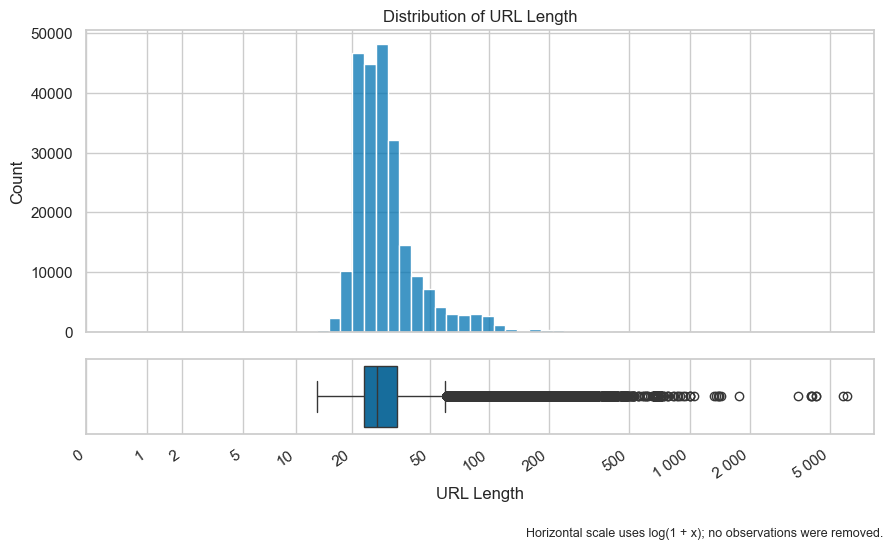

In [7]:
describe_feature("URLLength")
plot_log_hist_box("URLLength", "URL Length", bins=45)


**Discussion**

`URLLength` is extremely right-skewed. Its mean is approximately **34.57 characters**, while the median is **27**, showing that a small number of very long URLs pull the average upward. The standard deviation is approximately **41.31**, which is large relative to the mean.

The skewness (**53.32**) and kurtosis (**5914.01**) indicate an exceptionally long and heavy right tail. The maximum reaches **6,097 characters**, far beyond the typical URL. Therefore, the distribution is clearly non-Gaussian and heavy-tailed. The logarithmic visualization makes the central mass and the extreme tail visible at the same time without discarding data.


### 2. Domain Length

**Question:** What is the typical length of a domain and how variable is it?

`DomainLength` represents the total number of characters in the domain name.

**Analysis approach:** A histogram with a kernel density estimate is used because this is a numerical variable with a readable range on the original scale.


Feature: DomainLength
Mean: 21.4704
Standard deviation: 9.1508
Skewness: 2.5134
Kurtosis: 10.6602
Minimum: 4
Median: 20.0
Maximum: 110


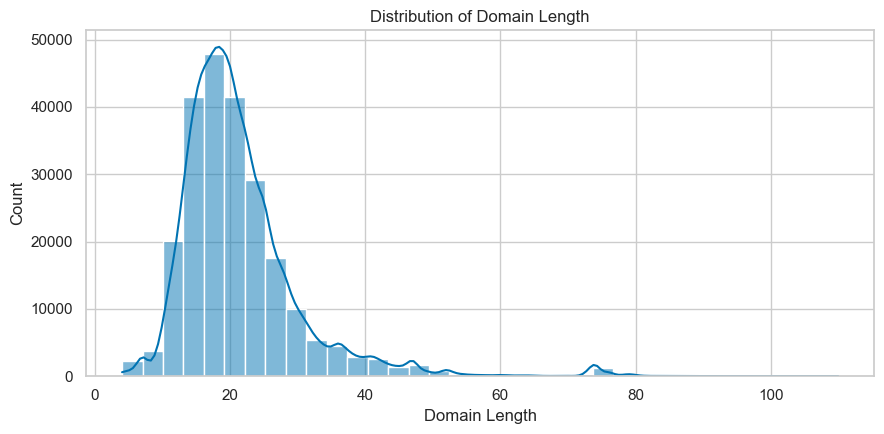

In [8]:
describe_feature("DomainLength")
plot_hist_kde("DomainLength", "Domain Length", bins=35)


**Discussion**

The distribution is right-skewed, but much less extreme than `URLLength`. The mean is approximately **21.47 characters** and the median is **20**, so most domains are concentrated around relatively short lengths. The standard deviation is approximately **9.15**.

The skewness of **2.51** confirms a substantial right tail, while the kurtosis of **10.66** indicates heavier tails and a sharper concentration than a Gaussian distribution. The maximum is **110 characters**, showing that unusually long domains exist but are uncommon.


### 3. URL Similarity Index

**Question:** How are URL similarity scores distributed?

`URLSimilarityIndex` is a similarity score associated with URL structure, bounded at 100.

**Analysis approach:** A histogram is retained, but the count axis is logarithmic because a very large concentration at the maximum value would otherwise visually hide the lower-frequency bins.


Feature: URLSimilarityIndex
Mean: 78.4308
Standard deviation: 28.9761
Skewness: -0.9899
Kurtosis: -0.4080
Minimum: 0.155574352
Median: 100.0
Maximum: 100.0


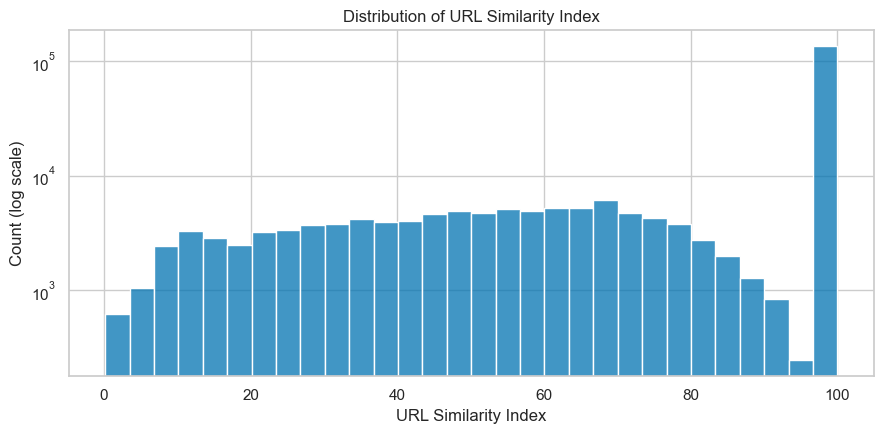

In [9]:
describe_feature("URLSimilarityIndex")
plot_spike_hist("URLSimilarityIndex", "URL Similarity Index", bins=30)


**Discussion**

The distribution is dominated by a strong concentration at **100**, which is also the median. The mean is approximately **78.43** and the standard deviation is approximately **28.98**. This difference between the mean and median reflects the long spread toward lower scores.

The skewness is approximately **-0.99**, confirming a left-skewed distribution. Kurtosis is approximately **-0.41**. The distribution is not Gaussian because a large share of the observations is concentrated at the upper boundary. The logarithmic count axis preserves this dominant spike while still making less frequent similarity scores visible.


### 4. Character Continuation Rate

**Question:** How is character continuity distributed across URLs?

`CharContinuationRate` measures the continuity of character sequences in a URL and ranges from 0 to 1.

**Analysis approach:** A histogram with a logarithmic count axis is used because the distribution has a strong boundary concentration at 1.0.


Feature: CharContinuationRate
Mean: 0.8455
Standard deviation: 0.2166
Skewness: -1.1286
Kurtosis: 0.0565
Minimum: 0.0
Median: 1.0
Maximum: 1.0


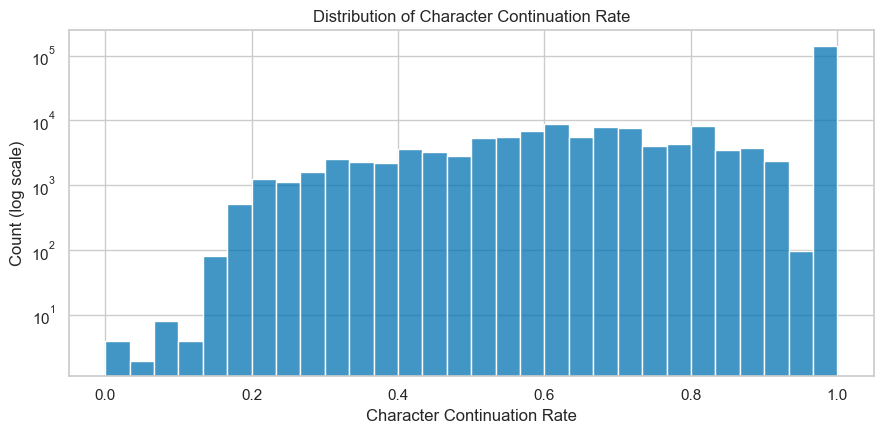

In [10]:
describe_feature("CharContinuationRate")
plot_spike_hist("CharContinuationRate", "Character Continuation Rate", bins=30)


**Discussion**

The variable is strongly concentrated near its upper boundary, with a median of **1.0** and a mean of approximately **0.846**. The standard deviation is approximately **0.217**.

Its skewness is approximately **-1.13**, showing a left tail extending toward lower continuation rates. The kurtosis is close to zero (**0.06**), but the pronounced mass at 1.0 means that the distribution should not be interpreted as Gaussian. The logarithmic count axis makes both the dominant boundary value and the smaller frequencies below it visible.


### 5. TLD Legitimate Probability

**Question:** How are legitimacy probabilities associated with top-level domains distributed?

`TLDLegitimateProb` represents the legitimacy probability associated with a top-level domain.

**Analysis approach:** A histogram on the original scale is used because the variable is bounded and concentrated around a small number of characteristic probability values.


Feature: TLDLegitimateProb
Mean: 0.2604
Standard deviation: 0.2516
Skewness: 0.0731
Kurtosis: -1.9738
Minimum: 0.0
Median: 0.0799628
Maximum: 0.5229071


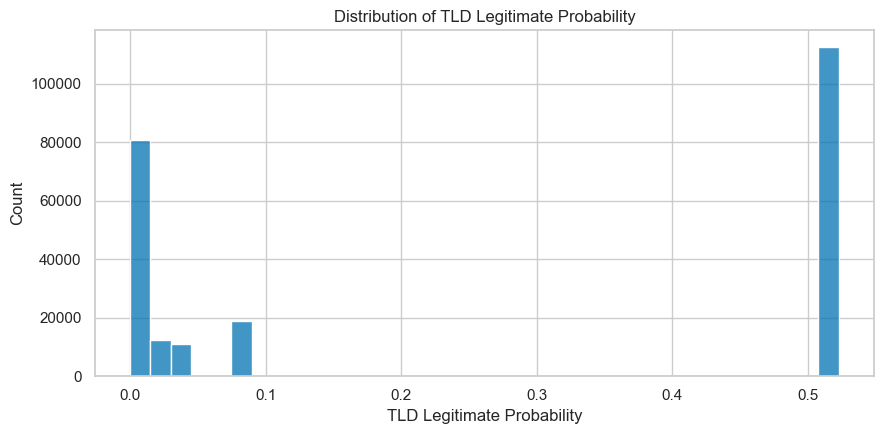

In [11]:
describe_feature("TLDLegitimateProb")
plt.figure(figsize=(9, 4.5))
sns.histplot(data=df, x="TLDLegitimateProb", bins=35)
plt.xlabel("TLD Legitimate Probability")
plt.ylabel("Count")
plt.title("Distribution of TLD Legitimate Probability")
plt.tight_layout()
plt.show()


**Discussion**

The distribution is clearly non-Gaussian and strongly clustered around a few probability values. The mean is approximately **0.260**, while the median is only **0.080**, and the standard deviation is approximately **0.252**.

Although the skewness is close to zero (**0.07**), this does not imply a normal distribution. The kurtosis of approximately **-1.97** reflects a very flat, polarized distribution. The histogram shows that the low skewness results from the balance between separated groups of values rather than from a bell-shaped distribution.


### 6. URL Character Probability

**Question:** What is the shape of the URL character probability distribution?

`URLCharProb` is a probability-based measure derived from the characters that compose a URL.

**Analysis approach:** A histogram with KDE is used because the feature is continuous and its distribution shape is informative on the original scale.


Feature: URLCharProb
Mean: 0.0557
Standard deviation: 0.0106
Skewness: -1.0643
Kurtosis: 1.4612
Minimum: 0.001082764
Median: 0.057970266
Maximum: 0.090823664


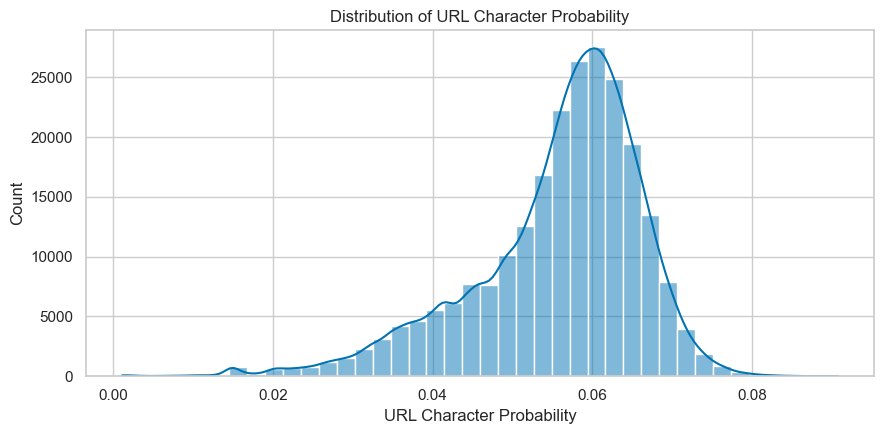

In [12]:
describe_feature("URLCharProb")
plot_hist_kde("URLCharProb", "URL Character Probability", bins=40)


**Discussion**

Most observations are concentrated around values close to **0.06**. The mean is approximately **0.0557**, the median is approximately **0.0580**, and the standard deviation is approximately **0.0106**, indicating a relatively narrow central region.

The skewness of approximately **-1.06** indicates a longer left tail. Kurtosis is approximately **1.46**, suggesting heavier tails and a sharper central concentration than a Gaussian distribution. The KDE makes this asymmetric shape easier to observe.


### 7. Number of Subdomains

**Question:** How many subdomains are typically present in the observed URLs?

`NoOfSubDomain` counts the number of subdomains present in a URL.

**Analysis approach:** A count plot is used because this is a discrete count variable with a small number of possible observed values. Percentages are displayed above the bars.


Feature: NoOfSubDomain
Mean: 1.1648
Standard deviation: 0.6010
Skewness: 1.8094
Kurtosis: 7.7881
Minimum: 0
Median: 1.0
Maximum: 10


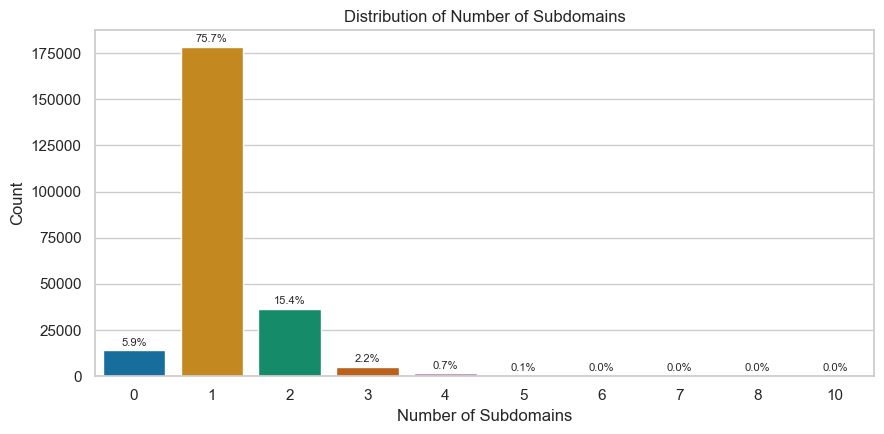

In [13]:
describe_feature("NoOfSubDomain")
plot_discrete_count("NoOfSubDomain", "Number of Subdomains")


**Discussion**

The distribution is concentrated at **1 subdomain**, which is also the median. The mean is approximately **1.16** and the standard deviation is approximately **0.60**, showing that most URLs remain close to this typical value.

The skewness is approximately **1.81**, indicating a right tail created by URLs with several subdomains. Kurtosis is approximately **7.79**, consistent with a pronounced peak and rare high counts. The maximum is **10 subdomains**, but such observations are uncommon.


### 8. Number of Letters in URL

**Question:** How many alphabetic characters are typically present in a URL?

`NoOfLettersInURL` counts alphabetic characters in the URL.

**Analysis approach:** The variable has an extreme right tail, so a log(1 + x) histogram and box plot are used to show the full distribution without excluding observations.


Feature: NoOfLettersInURL
Mean: 19.4289
Standard deviation: 29.0903
Skewness: 58.4026
Kurtosis: 8587.8936
Minimum: 0
Median: 14.0
Maximum: 5191


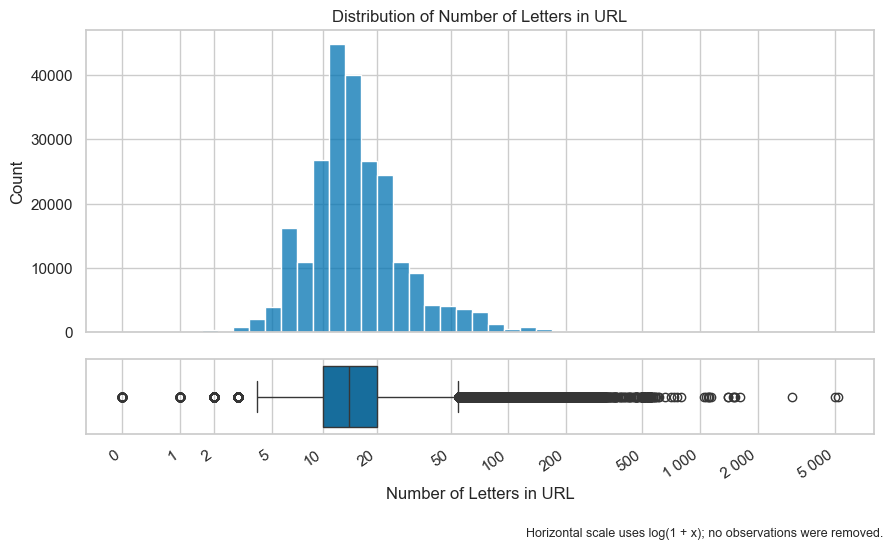

In [14]:
describe_feature("NoOfLettersInURL")
plot_log_hist_box("NoOfLettersInURL", "Number of Letters in URL", bins=45)


**Discussion**

The distribution is extremely right-skewed. The mean is approximately **19.43 letters**, while the median is **14**, and the standard deviation is approximately **29.09**. A small number of URLs therefore contain far more letters than the typical observation.

The skewness (**58.40**) and kurtosis (**8587.89**) indicate an exceptionally heavy right tail. The maximum reaches **5,191 letters**. This is a strongly non-Gaussian distribution, and the logarithmic visualization exposes both the common values and the rare extreme observations.


### 9. Letter Ratio in URL

**Question:** What proportion of URL characters are typically alphabetic?

`LetterRatioInURL` represents the proportion of alphabetic characters relative to total URL length.

**Analysis approach:** A violin plot with quartiles is used because the variable is continuous, bounded, and approximately symmetric. The violin shows density, spread, and central tendency simultaneously.


Feature: LetterRatioInURL
Mean: 0.5159
Standard deviation: 0.1233
Skewness: -0.0664
Kurtosis: 0.0159
Minimum: 0.0
Median: 0.519
Maximum: 0.926


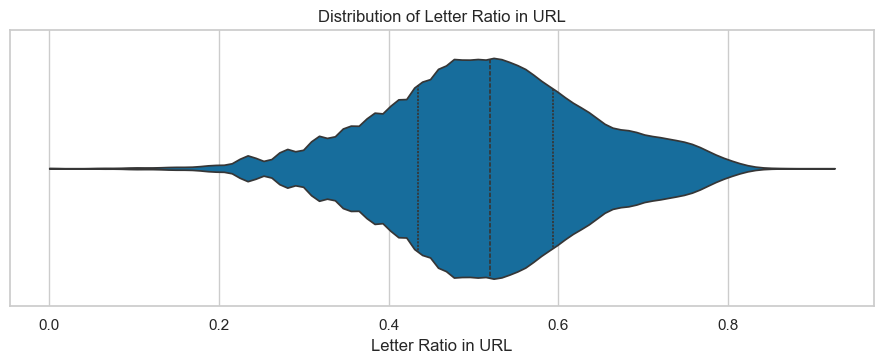

In [15]:
describe_feature("LetterRatioInURL")

plt.figure(figsize=(9, 3.8))
sns.violinplot(x=df["LetterRatioInURL"], inner="quart", cut=0)
plt.xlabel("Letter Ratio in URL")
plt.title("Distribution of Letter Ratio in URL")
plt.tight_layout()
plt.show()


**Discussion**

This is one of the most symmetric variables among the selected features. The mean is approximately **0.516** and the median is **0.519**, with a standard deviation of approximately **0.123**.

Skewness is approximately **-0.07** and kurtosis approximately **0.02**, both close to zero. These statistics indicate a distribution much closer to a symmetric, mesokurtic shape than the heavily skewed count variables. The violin plot also shows where observations are most densely concentrated while preserving the quartile information.


### 10. Number of Digits in URL

**Question:** How common are numeric characters in URLs, and how large can their counts become?

`NoOfDegitsInURL` counts numeric characters present in the URL.

**Analysis approach:** Because the variable is strongly zero-inflated and has extreme positive values, the visualization separates zero versus positive observations and then shows the positive distribution on a log(1 + x) scale.


Feature: NoOfDegitsInURL
Mean: 1.8810
Standard deviation: 11.8867
Skewness: 94.8776
Kurtosis: 14318.7891
Minimum: 0
Median: 0.0
Maximum: 2011


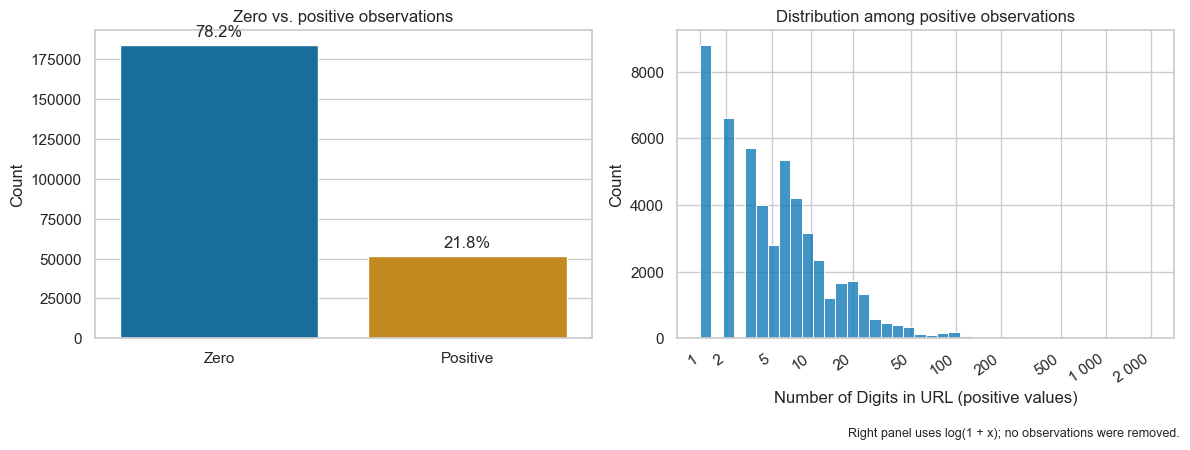

In [16]:
describe_feature("NoOfDegitsInURL")
plot_zero_inflated_count("NoOfDegitsInURL", "Number of Digits in URL", bins=40)


**Discussion**

The distribution is dominated by zero values: the median is **0**, while the mean is approximately **1.88**. The standard deviation is approximately **11.89**, substantially larger than the mean because a small number of observations contain very large digit counts.

The skewness is approximately **94.88** and kurtosis approximately **14318.79**, indicating an extremely heavy right tail. The maximum is **2,011 digits**. The two-panel visualization is more informative than a conventional histogram because it separately communicates the large zero mass and the shape of the positive observations.


### 11. Digit Ratio in URL

**Question:** What proportion of URL characters are digits?

`DegitRatioInURL` represents the proportion of numeric characters relative to total URL length.

**Analysis approach:** This ratio is also strongly zero-inflated. The visualization separates zero and positive observations, while the positive subset is shown with a histogram and KDE on the original ratio scale.


Feature: DegitRatioInURL
Mean: 0.0286
Standard deviation: 0.0709
Skewness: 3.2445
Kurtosis: 12.2363
Minimum: 0.0
Median: 0.0
Maximum: 0.684


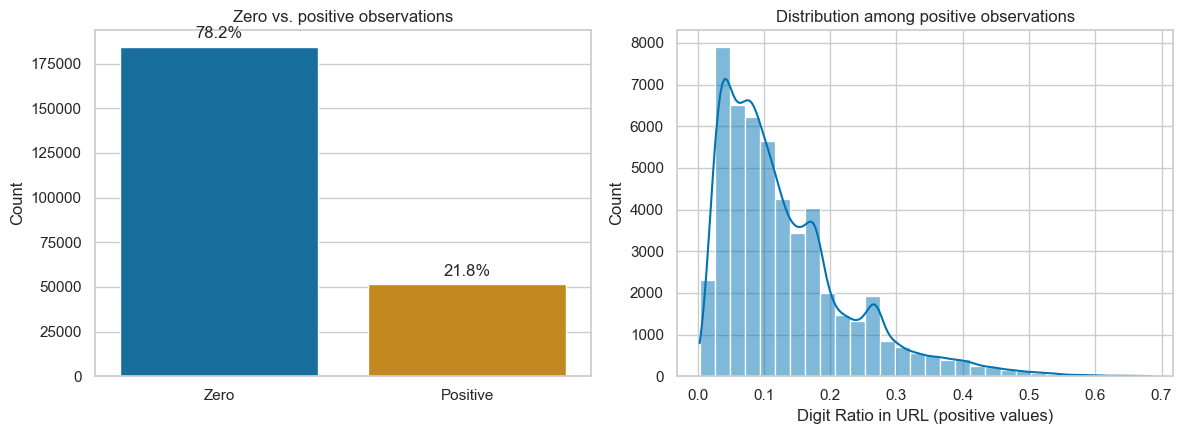

In [17]:
describe_feature("DegitRatioInURL")
plot_zero_inflated_ratio("DegitRatioInURL", "Digit Ratio in URL", bins=30)


**Discussion**

The median is **0**, showing that at least half of the URLs contain no numeric characters. The mean is approximately **0.0286** and the standard deviation approximately **0.0709**.

The positive skewness of approximately **3.24** and kurtosis of approximately **12.24** indicate a pronounced right tail and heavy-tail behavior. The maximum observed ratio is approximately **0.684**. Separating the zero mass from the positive values prevents the dominant zero bar from hiding the shape of the non-zero ratios.


### 12. Number of Other Special Characters in URL

**Question:** How many additional special characters are present in URLs?

`NoOfOtherSpecialCharsInURL` counts special characters not included in the dataset's other dedicated character categories.

**Analysis approach:** A log(1 + x) histogram with a box plot is used because the variable is a count with a long right tail.


Feature: NoOfOtherSpecialCharsInURL
Mean: 2.3402
Standard deviation: 3.5276
Skewness: 47.4285
Kurtosis: 5657.8683
Minimum: 0
Median: 1.0
Maximum: 499


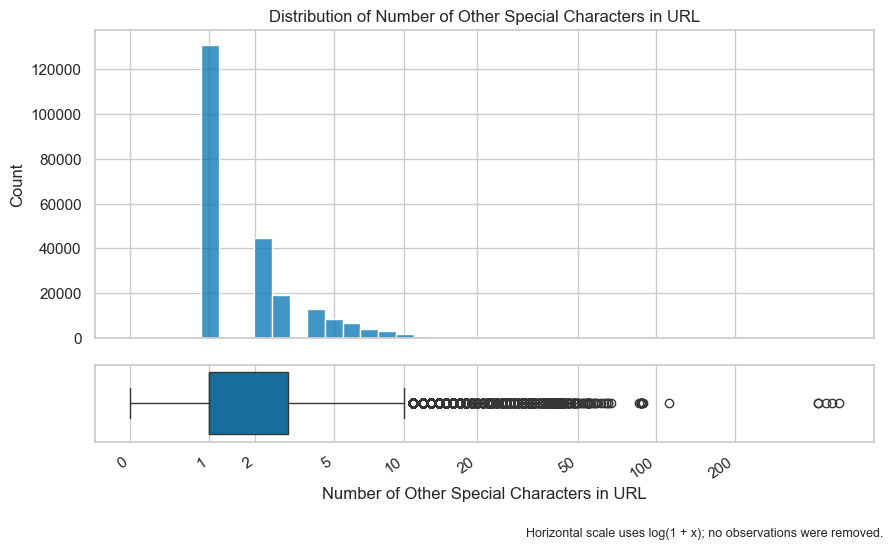

In [18]:
describe_feature("NoOfOtherSpecialCharsInURL")
plot_log_hist_box(
    "NoOfOtherSpecialCharsInURL",
    "Number of Other Special Characters in URL",
    bins=40
)


**Discussion**

Most URLs contain only a few such characters. The median is **1**, while the mean is approximately **2.34** and the standard deviation approximately **3.53**.

The skewness of approximately **47.43** and kurtosis of approximately **5657.87** reveal an extreme right tail generated by rare observations, with a maximum of **499**. Therefore, the distribution is highly non-Gaussian. The logarithmic view keeps these extreme values visible without allowing them to collapse the central part of the plot.


### 13. Special Character Ratio in URL

**Question:** What fraction of URL characters consists of special characters?

`SpacialCharRatioInURL` represents the proportion of special characters relative to total URL length.

**Analysis approach:** A histogram with KDE is used because the bounded continuous ratio remains readable on its original scale.


Feature: SpacialCharRatioInURL
Mean: 0.0633
Standard deviation: 0.0324
Skewness: 1.1841
Kurtosis: 0.9760
Minimum: 0.0
Median: 0.05
Maximum: 0.397


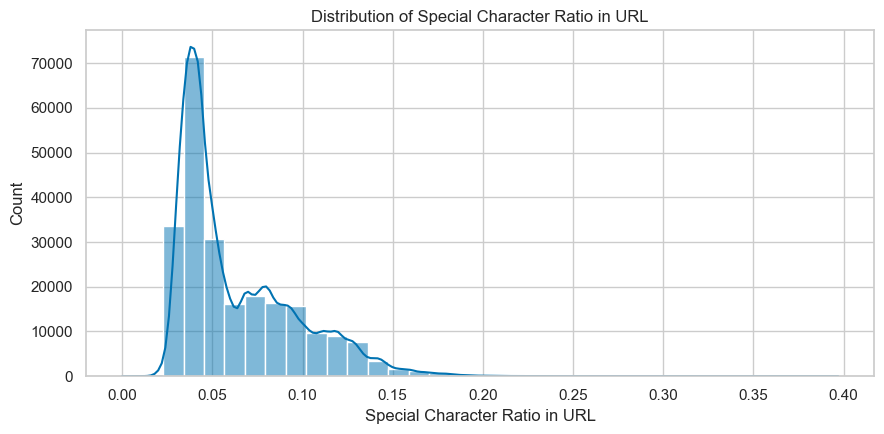

In [19]:
describe_feature("SpacialCharRatioInURL")
plot_hist_kde("SpacialCharRatioInURL", "Special Character Ratio in URL", bins=35)


**Discussion**

The distribution is positively skewed. The mean is approximately **0.0633**, the median **0.050**, and the standard deviation approximately **0.0324**. Most observations therefore have relatively low special-character ratios.

Skewness is approximately **1.18**, confirming the right tail. Kurtosis is approximately **0.98**, indicating somewhat heavier tails and a sharper concentration than a Gaussian distribution. The maximum ratio is approximately **0.397**.


### 14. HTTPS Usage

**Question:** How common is HTTPS usage among the webpages in the dataset?

`IsHTTPS` is a binary indicator showing whether a webpage uses HTTPS.

**Analysis approach:** A bar chart is appropriate because this is a binary categorical variable. Percentages are displayed directly on the bars.


Feature: IsHTTPS
Mean: 0.7826
Standard deviation: 0.4125
Skewness: -1.3704
Kurtosis: -0.1219
Minimum: 0
Median: 1.0
Maximum: 1


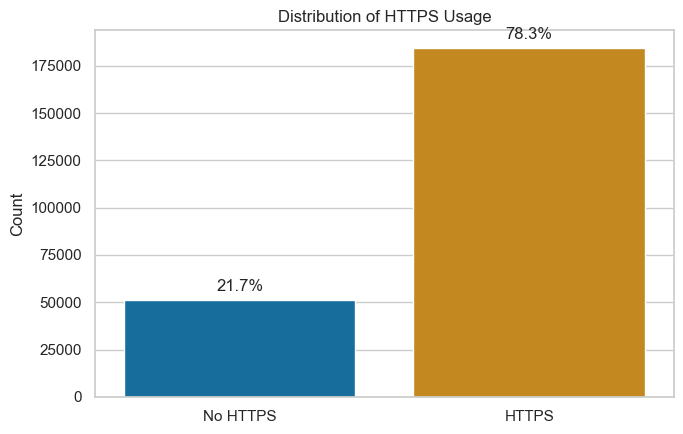

In [20]:
describe_feature("IsHTTPS")
plot_binary(
    "IsHTTPS",
    "HTTPS Usage",
    {0: "No HTTPS", 1: "HTTPS"}
)


**Discussion**

Approximately **78.3%** of the observations use HTTPS, corresponding to a mean of approximately **0.783** for this binary variable. The standard deviation is approximately **0.413**.

Because `IsHTTPS` follows a Bernoulli-type distribution, the mean can be interpreted directly as the proportion of observations with value 1. Its skewness is approximately **-1.37**, reflecting the dominance of HTTPS-enabled pages. HTTPS is therefore common in this dataset and should not be interpreted by itself as evidence that a webpage is legitimate.


### 15. Lines of Code

**Question:** How complex are webpages in terms of HTML source-code length?

`LineOfCode` represents the number of lines in the webpage's source code.

**Analysis approach:** The variable has an extreme right tail, so a log(1 + x) histogram and box plot are used to preserve all observations while keeping the distribution readable.


Feature: LineOfCode
Mean: 1141.9004
Standard deviation: 3419.9505
Skewness: 53.0723
Kurtosis: 5597.1973
Minimum: 2
Median: 429.0
Maximum: 442666


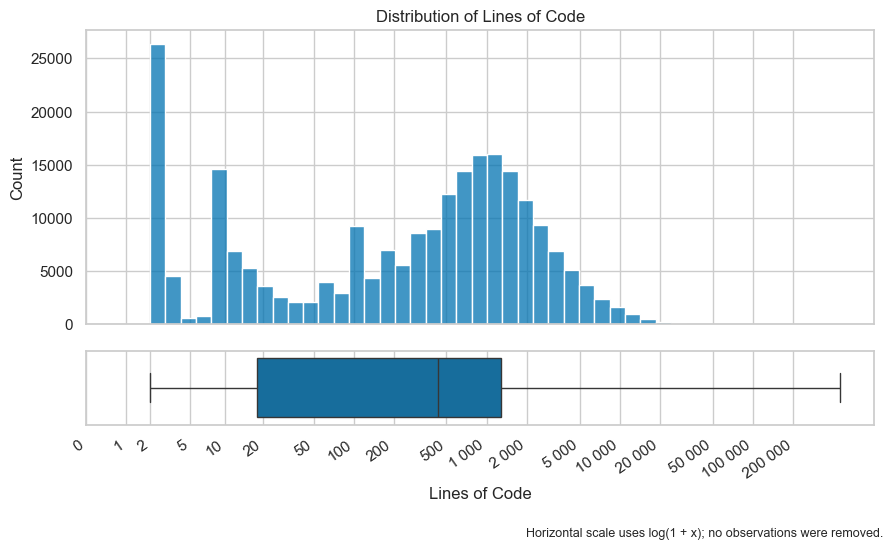

In [21]:
describe_feature("LineOfCode")
plot_log_hist_box("LineOfCode", "Lines of Code", bins=45)


**Discussion**

`LineOfCode` is extremely right-skewed. The mean is approximately **1,141.90 lines**, while the median is only **429**, and the standard deviation is approximately **3,419.95**.

The skewness (**53.07**) and kurtosis (**5597.20**) show an exceptionally heavy right tail. The maximum reaches **442,666 lines**, far beyond the typical webpage. The logarithmic visualization is therefore necessary to show both common page sizes and very large pages without discarding any records.


### 16. Domain-Title Match Score

**Question:** How strongly does the webpage title match its domain?

`DomainTitleMatchScore` quantifies the degree of consistency between the domain and the webpage title on a 0 to 100 scale.

**Analysis approach:** A histogram with a logarithmic count axis is used because the feature is highly polarized, with large concentrations at boundary values and relatively few intermediate scores.


Feature: DomainTitleMatchScore
Mean: 50.1314
Standard deviation: 49.6770
Skewness: -0.0087
Kurtosis: -1.9927
Minimum: 0.0
Median: 75.0
Maximum: 100.0


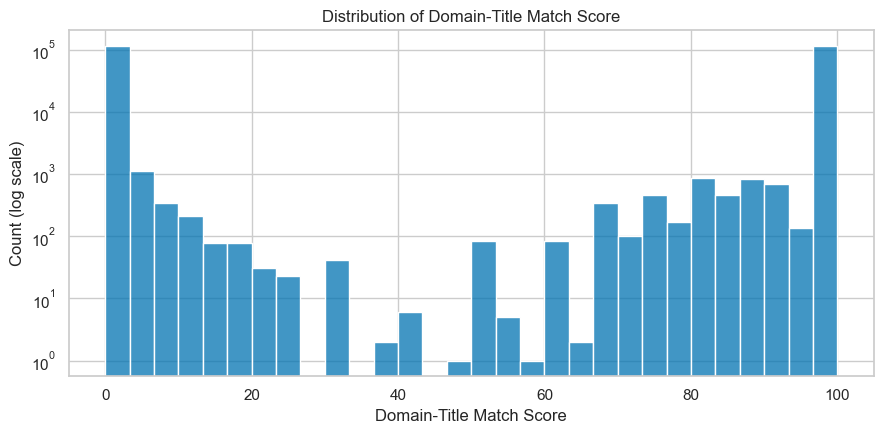

In [22]:
describe_feature("DomainTitleMatchScore")
plot_spike_hist("DomainTitleMatchScore", "Domain-Title Match Score", bins=30)


**Discussion**

The distribution is strongly polarized rather than bell-shaped. Approximately **48.2%** of the observations have score **0**, while many observations are concentrated near **100**. The mean is approximately **50.13**, the median is **75**, and the standard deviation is approximately **49.68**.

Skewness is almost zero (**-0.009**), but this should not be mistaken for normality. The kurtosis is approximately **-1.99**, which is consistent with a flat, strongly separated distribution. The log-count histogram is useful here because it shows both the dominant boundary values and the much less frequent intermediate scores.


### 17. URL-Title Match Score

**Question:** How strongly does the webpage title match its URL?

`URLTitleMatchScore` quantifies consistency between the URL text and the webpage title on a 0 to 100 scale.

**Analysis approach:** A histogram with a logarithmic count axis is used because the distribution is dominated by the two boundary values.


Feature: URLTitleMatchScore
Mean: 52.1221
Standard deviation: 49.6006
Skewness: -0.0891
Kurtosis: -1.9845
Minimum: 0.0
Median: 100.0
Maximum: 100.0


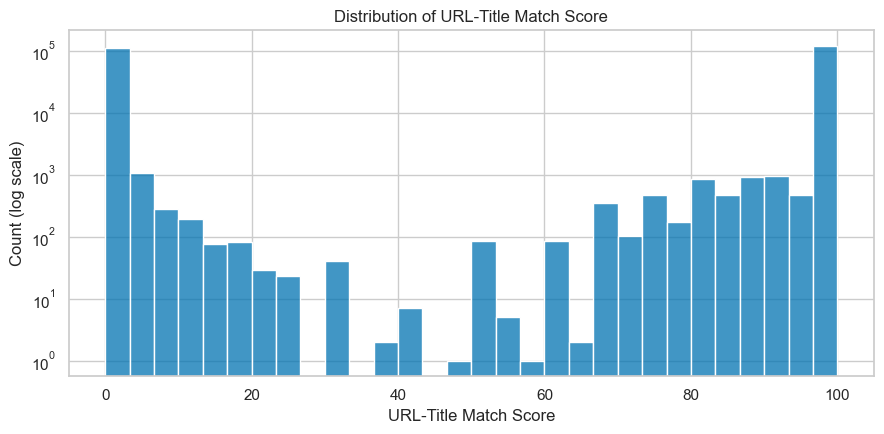

In [23]:
describe_feature("URLTitleMatchScore")
plot_spike_hist("URLTitleMatchScore", "URL-Title Match Score", bins=30)


**Discussion**

This feature is even more strongly polarized. Approximately **45.5%** of the observations have score **0**, while about **50.1%** have score **100**. The mean is approximately **52.12**, the median is **100**, and the standard deviation is approximately **49.60**.

Skewness is close to zero (**-0.09**) because the large masses at the two extremes roughly balance each other. Kurtosis is approximately **-1.98**, which is characteristic of a very flat, bimodal-like distribution rather than a Gaussian one. The log-count scale reveals the small set of intermediate match scores that would otherwise be almost invisible.


### 18. Number of Images

**Question:** How many images are typically embedded in the webpages?

`NoOfImage` counts image elements found in the webpage content.

**Analysis approach:** The variable is zero-inflated and highly right-skewed, so zero versus positive observations are shown separately from the positive-value distribution, which uses a log(1 + x) horizontal scale.


Feature: NoOfImage
Mean: 26.0757
Standard deviation: 79.4118
Skewness: 28.2303
Kurtosis: 1785.8073
Minimum: 0
Median: 8.0
Maximum: 8956


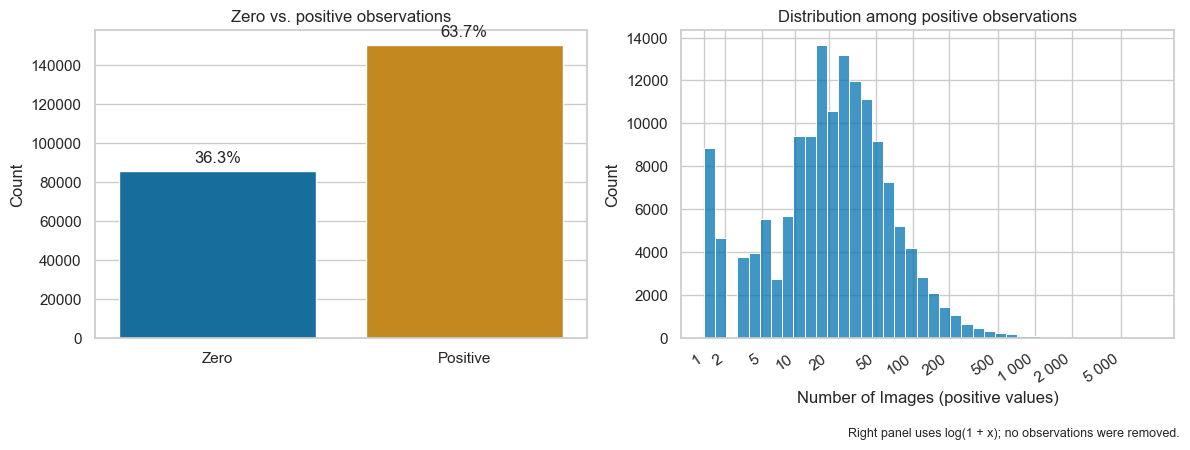

In [24]:
describe_feature("NoOfImage")
plot_zero_inflated_count("NoOfImage", "Number of Images", bins=40)


**Discussion**

The distribution contains a substantial zero mass: approximately **36.3%** of pages have no detected images. The median is **8 images**, while the mean is approximately **26.08** and the standard deviation approximately **79.41**, indicating that large counts strongly influence the average.

Skewness is approximately **28.23** and kurtosis approximately **1785.81**, confirming a very heavy right tail. The maximum is **8,956 images**. Separating zero and positive observations gives a clearer description than a single conventional histogram.


### 19. Number of Self References

**Question:** How many hyperlinks on a webpage refer back to the same site?

`NoOfSelfRef` counts self-referencing hyperlinks.

**Analysis approach:** A zero-versus-positive bar chart is paired with a log(1 + x) histogram of positive counts because the variable is both zero-inflated and extremely right-skewed.


Feature: NoOfSelfRef
Mean: 65.0711
Standard deviation: 176.6875
Skewness: 60.3814
Kurtosis: 7648.0475
Minimum: 0
Median: 12.0
Maximum: 27397


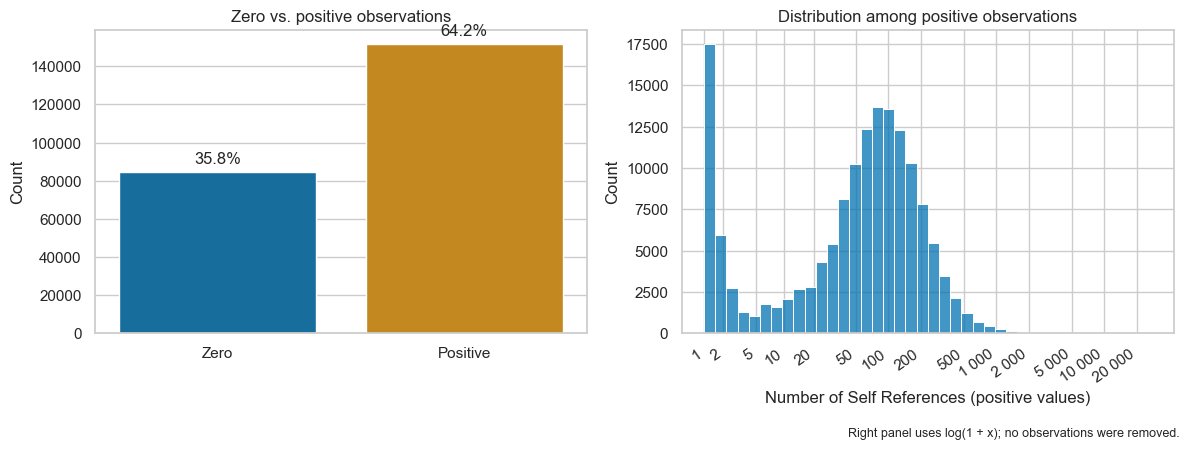

In [25]:
describe_feature("NoOfSelfRef")
plot_zero_inflated_count("NoOfSelfRef", "Number of Self References", bins=40)


**Discussion**

Approximately **35.8%** of observations have no self references. The median is **12**, while the mean is approximately **65.07** and the standard deviation approximately **176.69**, showing that a relatively small set of pages contains very large numbers of internal links.

The skewness is approximately **60.38** and kurtosis approximately **7648.05**, indicating an extreme heavy right tail. The maximum reaches **27,397 self references**. The split visualization prevents the zero mass and the extreme values from obscuring the central behavior.


### 20. Number of External References

**Question:** How many hyperlinks on a webpage point to external sites?

`NoOfExternalRef` counts hyperlinks that refer to external domains.

**Analysis approach:** The feature is zero-inflated and highly right-skewed, so zero versus positive observations are shown separately and the positive distribution is displayed using a log(1 + x) horizontal scale.


Feature: NoOfExternalRef
Mean: 49.2625
Standard deviation: 161.0274
Skewness: 65.9002
Kurtosis: 8289.6472
Minimum: 0
Median: 10.0
Maximum: 27516


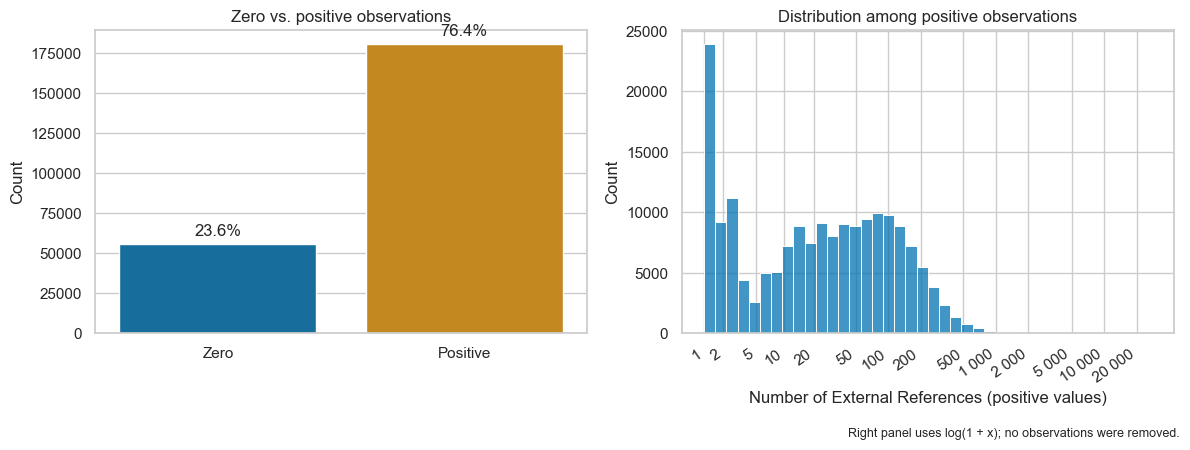

In [26]:
describe_feature("NoOfExternalRef")
plot_zero_inflated_count("NoOfExternalRef", "Number of External References", bins=40)


**Discussion**

Approximately **23.6%** of observations have no external references. The median is **10**, the mean is approximately **49.26**, and the standard deviation is approximately **161.03**. The large difference between the mean and median indicates strong influence from rare high counts.

The skewness is approximately **65.90** and kurtosis approximately **8289.65**, confirming an extreme right tail. The maximum reaches **27,516 external references**. The two-panel visualization shows the zero mass and the positive-value distribution without removing or clipping any observations.


# Multivariate data analysis

In this section, you should plot at least **5 multivariate visualizations**. The key here is to investigate underlying correlations and behaviors within the dataset.
Naturally, as visualizations are being created, we should end up with obvious results, yet, you should find at least **ONE** non-obvious behavior in the data.

Please follow these steps for creating your visualizations:
1. State an hypothesis. Explain why you have selected these specific variables and what you expect to discover through their relationship;
2. Determine what kind of visualization is the most suitable;
3. Report the findings and discuss whether they corroborate or not the aforementioned hypothesis.


**Hints**

In this section, make sure you go beyond naive explorations. For example, consider applying techniques such as PCA, t-SNE, or even others that we haven't covered in the lectures. The goal is to cultivate a critical mindset toward data analysis and our work.

**Important**

It is strictly prohibited to create multivariate visualizations using variables that were not included in the previous section (univariate data analysis).

### 1. URL Length vs. Class

**Question:** Do phishing and legitimate webpages present different URL-length distributions?

**Hypothesis:** Phishing URLs are expected to be longer because they may contain additional paths, parameters, subdomains, or misleading text intended to imitate legitimate services.

**Variables:** `URLLength` and `label`.

**Visualization choice:** A violin plot is used because `URLLength` is numerical and `label` is categorical. Because URL length has an extreme right tail, the plot uses `log(1 + URLLength)` only for the visualization. The summary table remains in the original unit of characters.


,count,median,mean,std
Class,,,,
Legitimate,134850,26.0,26.23,4.82
Phishing,100945,34.0,45.72,61.15


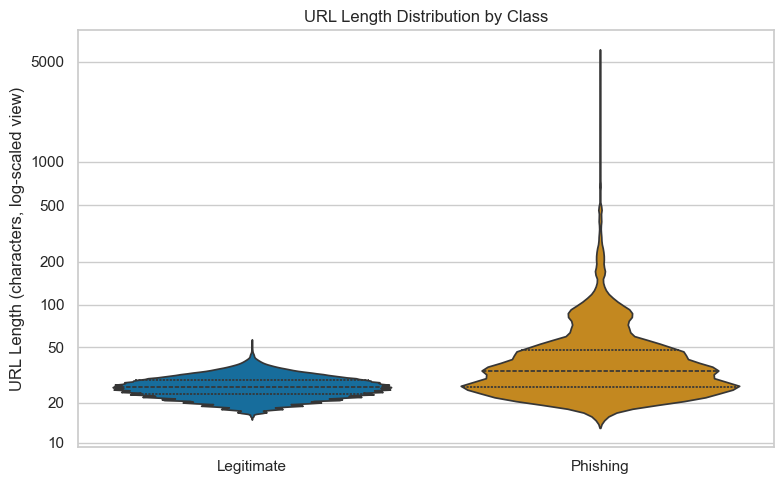

In [27]:
url_length_summary = (
    df.assign(Class=df["label"].map({0: "Phishing", 1: "Legitimate"}))
      .groupby("Class")["URLLength"]
      .agg(["count", "median", "mean", "std"])
      .round(2)
)

display(url_length_summary)

plot_df = df.assign(
    Class=df["label"].map({0: "Phishing", 1: "Legitimate"}),
    URLLengthLog=np.log1p(df["URLLength"])
)

plt.figure(figsize=(8, 5))
sns.violinplot(
    data=plot_df,
    x="Class",
    y="URLLengthLog",
    hue="Class",
    palette="colorblind",
    legend=False,
    inner="quart",
    cut=0
)

tick_values = [10, 20, 50, 100, 200, 500, 1000, 5000]
tick_values = [v for v in tick_values if v <= df["URLLength"].max()]
plt.yticks(np.log1p(tick_values), [str(v) for v in tick_values])

plt.xlabel("")
plt.ylabel("URL Length (characters, log-scaled view)")
plt.title("URL Length Distribution by Class")
plt.tight_layout()
plt.show()


**Discussion**

The results support the hypothesis. Legitimate URLs have a median length of **26 characters** and a mean of **26.23**, whereas phishing URLs have a median of **34 characters** and a substantially higher mean of **45.72**.

The difference in variability is also pronounced. Legitimate URLs have a standard deviation of only **4.82**, while phishing URLs have a standard deviation of **61.15**. The violin plot shows that legitimate URLs are tightly concentrated around relatively short lengths, while phishing URLs are distributed over a much wider range and include a long upper tail.

Therefore, URL length alone does not define whether a page is phishing, but the observed distributions indicate that phishing URLs in this dataset tend to be longer and much more variable than legitimate URLs. The median is especially useful here because the phishing distribution contains extreme values that strongly affect the mean.


### 2. URL Similarity Index vs. Class

**Question:** Does the structural similarity score differ between phishing and legitimate webpages?

**Hypothesis:** Legitimate webpages are expected to have higher `URLSimilarityIndex` values, while phishing webpages should be more concentrated at lower similarity scores.

**Variables:** `URLSimilarityIndex` and `label`.

**Visualization choice:** Class-specific normalized step histograms are used. They allow the complete 0–100 range to be compared without one class dominating the other simply because of class size.


,count,median,mean,std
Class,,,,
Legitimate,134850,100.00,100.00,0.00
Phishing,100945,51.42,49.62,22.57


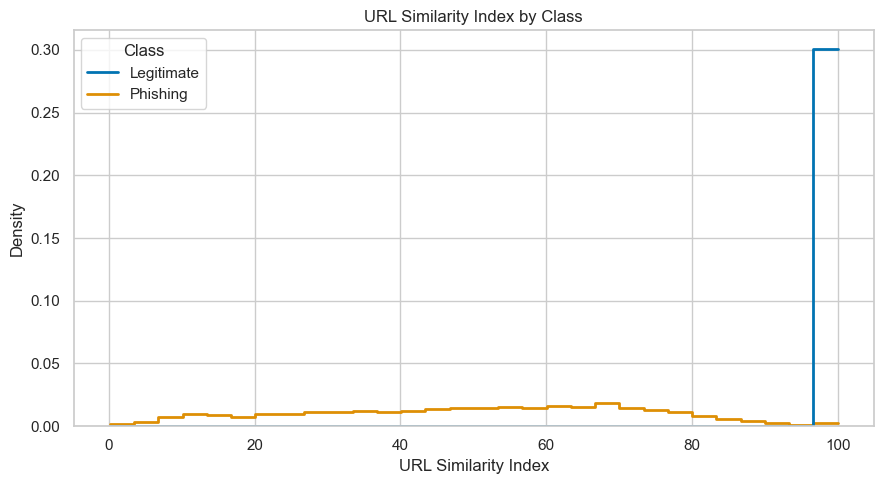

In [28]:
similarity_summary = (
    df.assign(Class=df["label"].map({0: "Phishing", 1: "Legitimate"}))
      .groupby("Class")["URLSimilarityIndex"]
      .agg(["count", "median", "mean", "std"])
      .round(2)
)

display(similarity_summary)

plot_df = df.assign(
    Class=df["label"].map({0: "Phishing", 1: "Legitimate"})
)

plt.figure(figsize=(9, 5))
sns.histplot(
    data=plot_df,
    x="URLSimilarityIndex",
    hue="Class",
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    palette="colorblind",
    linewidth=2
)

plt.xlabel("URL Similarity Index")
plt.ylabel("Density")
plt.title("URL Similarity Index by Class")
plt.tight_layout()
plt.show()


**Discussion**

The difference between the two classes is extremely pronounced. All legitimate observations have a `URLSimilarityIndex` of **100**, resulting in a median and mean of **100.00** and a standard deviation of **0.00**.

Phishing webpages behave very differently: their median similarity index is **51.42**, the mean is **49.62**, and the standard deviation is **22.57**. Their values are spread across a broad portion of the scale instead of being concentrated exclusively at the upper boundary.

The hypothesis is therefore strongly supported. In this dataset, maximum URL similarity is a defining characteristic of the legitimate class, whereas phishing webpages exhibit substantially lower and more heterogeneous similarity scores. This makes `URLSimilarityIndex` one of the clearest candidate features for distinguishing the two classes.


### 3. HTTPS Usage vs. Class

**Question:** Is the proportion of phishing webpages different between pages that use HTTPS and pages that do not?

**Hypothesis:** Pages without HTTPS are expected to contain a higher proportion of phishing observations. However, HTTPS alone is not expected to be a reliable indicator of legitimacy because phishing sites can also obtain valid TLS certificates.

**Variables:** `IsHTTPS` and `label`.

**Visualization choice:** A 100% stacked bar chart is used because both variables are categorical. Each bar represents the class composition within an HTTPS category, making the comparison independent of the number of observations in each category.


label,Legitimate,Phishing
IsHTTPS,,
No HTTPS,0.00,100.00
HTTPS,73.07,26.93


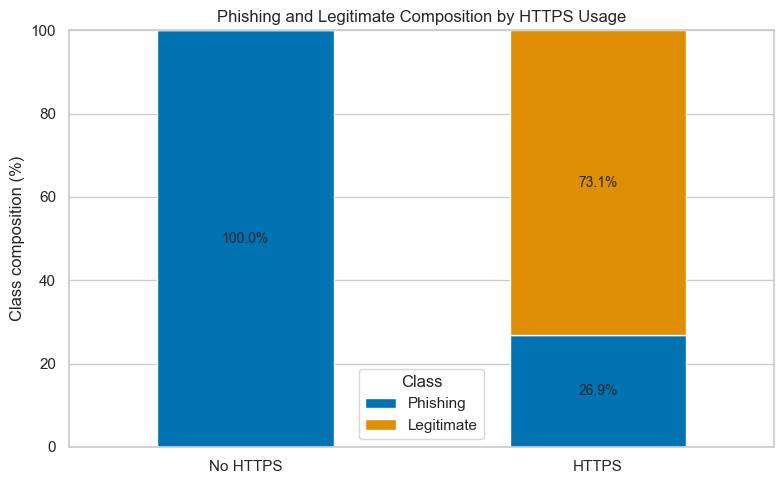

In [29]:
https_class = pd.crosstab(
    df["IsHTTPS"].map({0: "No HTTPS", 1: "HTTPS"}),
    df["label"].map({0: "Phishing", 1: "Legitimate"}),
    normalize="index"
).mul(100)

https_class = https_class.reindex(["No HTTPS", "HTTPS"])
display(https_class.round(2))

colors = sns.color_palette("colorblind", 2)

ax = https_class[["Phishing", "Legitimate"]].plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=colors
)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%" if bar.get_height() >= 4 else ""
        for bar in container
    ]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=10)

plt.xlabel("")
plt.ylabel("Class composition (%)")
plt.title("Phishing and Legitimate Composition by HTTPS Usage")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title="Class")
plt.tight_layout()
plt.show()


**Discussion**

The relationship between HTTPS usage and class is strong. Among webpages without HTTPS, **100% of the observations are phishing**. In contrast, webpages using HTTPS are composed of approximately **73.07% legitimate** and **26.93% phishing** observations.

The hypothesis is supported in the sense that absence of HTTPS is strongly associated with phishing in this dataset. However, the result also demonstrates an important limitation: HTTPS is not evidence that a webpage is legitimate. More than one quarter of HTTPS-enabled observations are still phishing.

Therefore, `IsHTTPS` is informative but should not be interpreted as a standalone security indicator. HTTPS describes whether the connection is encrypted, not whether the destination itself is trustworthy.


### 4. Number of Subdomains vs. Class

**Question:** Does the class composition change as the number of subdomains increases?

**Hypothesis:** URLs with several subdomains are expected to contain a larger proportion of phishing instances because attackers may use additional subdomains to imitate trusted names or make the actual registered domain less obvious.

**Variables:** `NoOfSubDomain` and `label`.

**Visualization choice:** A 100% stacked bar chart is used. Counts of four or more subdomains are grouped only for visualization because those values are rare; no observations are discarded.


label,Legitimate,Phishing
NoOfSubDomain,,
0,0.00,100.00
1,64.38,35.62
2,50.17,49.83
3,33.03,66.97
4+,3.10,96.90


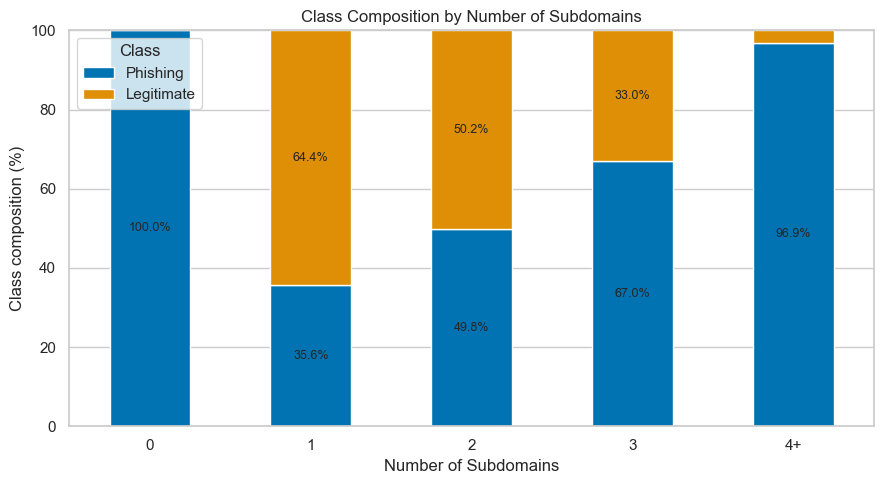

In [30]:
subdomain_group = df["NoOfSubDomain"].apply(
    lambda x: "4+" if x >= 4 else str(int(x))
)

subdomain_class = pd.crosstab(
    subdomain_group,
    df["label"].map({0: "Phishing", 1: "Legitimate"}),
    normalize="index"
).mul(100)

order = ["0", "1", "2", "3", "4+"]
subdomain_class = subdomain_class.reindex(
    [x for x in order if x in subdomain_class.index]
)

display(subdomain_class.round(2))

colors = sns.color_palette("colorblind", 2)

ax = subdomain_class[["Phishing", "Legitimate"]].plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    color=colors
)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%" if bar.get_height() >= 4 else ""
        for bar in container
    ]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9)

plt.xlabel("Number of Subdomains")
plt.ylabel("Class composition (%)")
plt.title("Class Composition by Number of Subdomains")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title="Class")
plt.tight_layout()
plt.show()


**Discussion**

The results show a strong relationship between the number of subdomains and the class, but the pattern is not completely monotonic.

For URLs with **1 subdomain**, phishing represents **35.62%** of observations. This increases to **49.83%** with 2 subdomains, **66.97%** with 3, and **96.90%** for URLs with 4 or more subdomains. Among URLs containing at least one subdomain, this progression strongly supports the hypothesis that additional subdomains are associated with a higher phishing proportion.

A notable exception occurs for URLs with **0 subdomains**, where **100% of observations are phishing**. This is an important non-obvious behavior because it shows that the relationship cannot be summarized simply as “more subdomains means more phishing.” Instead, the class distribution changes substantially according to URL structure, with both the absence of subdomains and very high subdomain counts being strongly associated with phishing in this dataset.


### 5. Domain-Title Match, URL-Title Match, and Class

**Question:** How does the joint relationship between domain-title consistency and URL-title consistency differ between phishing and legitimate webpages?

**Hypothesis:** Legitimate webpages are expected to concentrate where both match scores are high, while phishing webpages should appear more frequently in regions where one or both scores are low.

**Variables:** `DomainTitleMatchScore`, `URLTitleMatchScore`, and `label`.

**Visualization choice:** A two-dimensional difference heatmap is used. Each class is first normalized independently over the same 0–100 score grid, and the phishing distribution is then subtracted from the legitimate distribution. This avoids the severe overplotting of a scatterplot and makes the regions associated more strongly with each class directly visible.


DomainTitleMatchScore        URLTitleMatchScore       
                          median   mean             median   mean
Class                                                            
Legitimate                 100.0  75.27              100.0  75.27
Phishing                     0.0  16.55                0.0  21.20

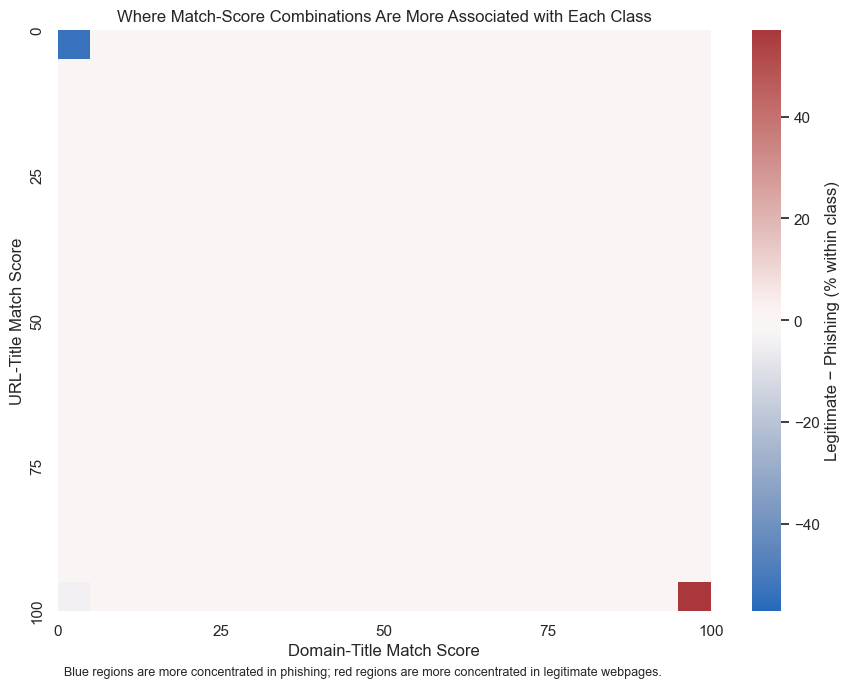

In [31]:
joint_summary = (
    df.assign(Class=df["label"].map({0: "Phishing", 1: "Legitimate"}))
      .groupby("Class")[["DomainTitleMatchScore", "URLTitleMatchScore"]]
      .agg(["median", "mean"])
      .round(2)
)

display(joint_summary)

bins = np.linspace(0, 100, 21)

phishing = df[df["label"] == 0]
legitimate = df[df["label"] == 1]

phishing_hist, _, _ = np.histogram2d(
    phishing["DomainTitleMatchScore"],
    phishing["URLTitleMatchScore"],
    bins=[bins, bins]
)

legitimate_hist, _, _ = np.histogram2d(
    legitimate["DomainTitleMatchScore"],
    legitimate["URLTitleMatchScore"],
    bins=[bins, bins]
)

# Normalize each class independently so that class size does not drive the comparison.
phishing_pct = phishing_hist / phishing_hist.sum() * 100
legitimate_pct = legitimate_hist / legitimate_hist.sum() * 100

difference = legitimate_pct - phishing_pct
limit = np.abs(difference).max()

plt.figure(figsize=(9, 7))
ax = sns.heatmap(
    difference.T,
    cmap="vlag",
    center=0,
    vmin=-limit,
    vmax=limit,
    cbar_kws={"label": "Legitimate − Phishing (% within class)"}
)

tick_positions = np.arange(0, 21, 5)
tick_labels = [0, 25, 50, 75, 100]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)

plt.xlabel("Domain-Title Match Score")
plt.ylabel("URL-Title Match Score")
plt.title("Where Match-Score Combinations Are More Associated with Each Class")

plt.text(
    0.01, -0.11,
    "Blue regions are more concentrated in phishing; red regions are more concentrated in legitimate webpages.",
    transform=ax.transAxes,
    fontsize=9
)

plt.tight_layout()
plt.show()


**Discussion**

The summary statistics show a clear joint difference between the classes. Legitimate webpages have a median of **100** for both `DomainTitleMatchScore` and `URLTitleMatchScore`, with a mean of **75.27** for each feature. Phishing webpages have a median of **0** for both scores, with much lower means of **16.55** for domain-title matching and **21.20** for URL-title matching.

These results strongly support the hypothesis: legitimate pages are characterized by substantially greater consistency between their domain, URL, and page title, while phishing pages are concentrated toward low match scores.

The difference heatmap is designed to emphasize this contrast directly. Regions toward high values on both axes should be associated more strongly with legitimate webpages, whereas low-score combinations should be associated more strongly with phishing. Examining the two scores jointly is useful because it captures consistency across multiple components of a webpage rather than relying on either score in isolation.


# Final Plots (Effective Data Visualization)

In this section, you need to **enhance 3 multivariate visualizations** that were presented in the previous section of the report.
The goal is to enhance these visualizations so that they can be effectively presented to an audience unfamiliar with the dataset or with data analysis.
**Therefore, make sure that their size, colors, textures, and other visual elements are appropriate and convey the intended information to the audience.**

For your final plots, make sure you follow these steps:
1. Present the plot;
2. Provide a description of the visualization, highlighting the key findings that can be drawn from it.


**Hint**: take a look at the checklist based on Evergreen’s work to ensure your visualizations meet the best practices for clarity and impact.

## Final Visualization 1 — URL Length by Class

This visualization highlights the difference in URL length between phishing and legitimate webpages. The violin shapes show the full distribution, while the white markers identify the class medians in the original unit of characters.

The main finding is that phishing URLs are not only longer on average, but also substantially more variable. The median increases from **26 characters for legitimate URLs to 34 for phishing URLs**, while the phishing distribution extends much further toward long URLs.


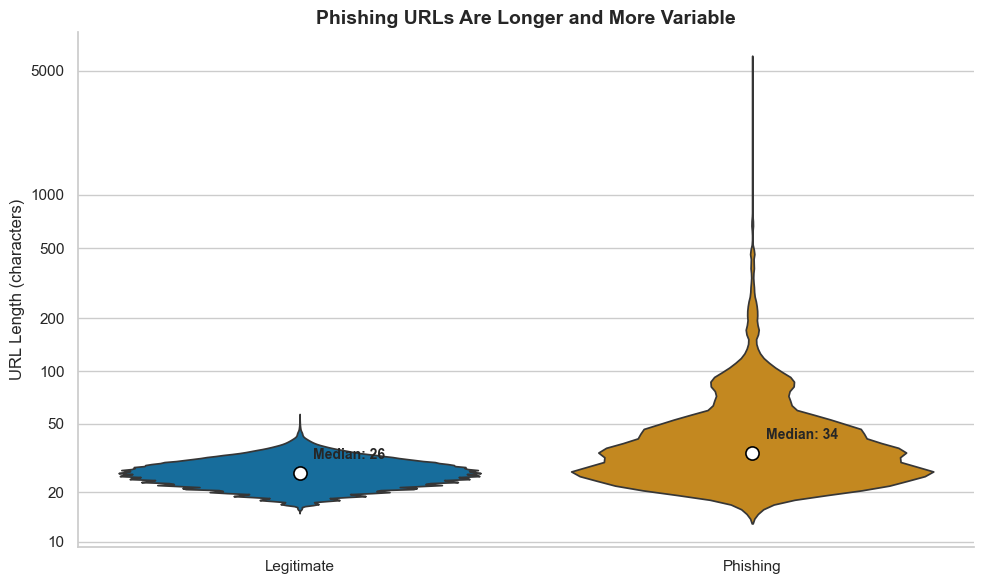

In [32]:
final_url = df.assign(
    Class=df["label"].map({0: "Phishing", 1: "Legitimate"}),
    URLLengthLog=np.log1p(df["URLLength"])
)

class_order = ["Legitimate", "Phishing"]
median_values = (
    final_url.groupby("Class")["URLLength"]
    .median()
    .reindex(class_order)
)

plt.figure(figsize=(10, 6))

ax = sns.violinplot(
    data=final_url,
    x="Class",
    y="URLLengthLog",
    order=class_order,
    hue="Class",
    palette="colorblind",
    legend=False,
    inner=None,
    cut=0
)

for x, class_name in enumerate(class_order):
    median = median_values[class_name]
    ax.scatter(
        x,
        np.log1p(median),
        s=90,
        facecolor="white",
        edgecolor="black",
        linewidth=1.2,
        zorder=5
    )
    ax.annotate(
        f"Median: {median:.0f}",
        (x, np.log1p(median)),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=10,
        weight="bold"
    )

tick_values = [10, 20, 50, 100, 200, 500, 1000, 5000]
tick_values = [v for v in tick_values if v <= df["URLLength"].max()]
ax.set_yticks(np.log1p(tick_values))
ax.set_yticklabels([str(v) for v in tick_values])

ax.set_xlabel("")
ax.set_ylabel("URL Length (characters)")
ax.set_title(
    "Phishing URLs Are Longer and More Variable",
    fontsize=14,
    weight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()


## Final Visualization 2 — HTTPS Usage and Class

This chart presents the phishing/legitimate composition within each HTTPS category. Using percentages rather than raw counts makes the groups directly comparable even though they contain different numbers of observations.

The strongest result is that **every webpage without HTTPS in this dataset is phishing**. However, HTTPS is not sufficient to establish legitimacy: **26.93% of HTTPS-enabled webpages are still phishing**. The visualization therefore communicates both the strong association between HTTPS usage and class and the limitation of treating HTTPS as a standalone legitimacy indicator.


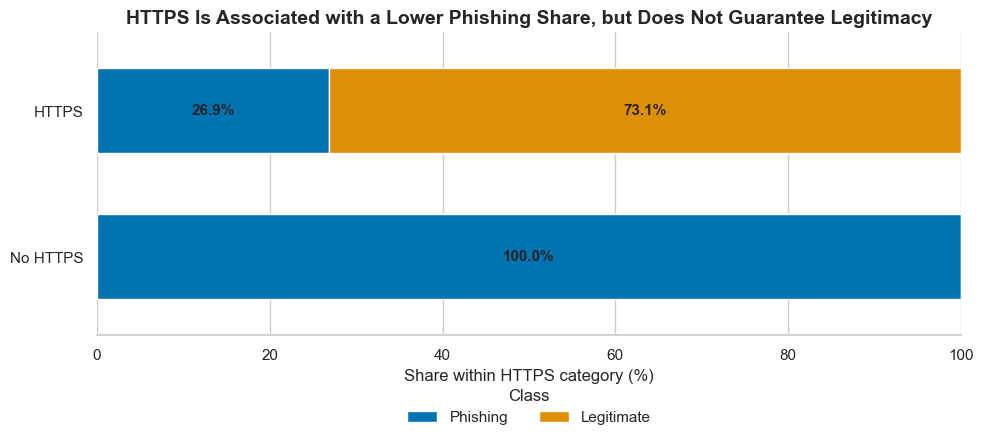

In [33]:
https_final = pd.crosstab(
    df["IsHTTPS"].map({0: "No HTTPS", 1: "HTTPS"}),
    df["label"].map({0: "Phishing", 1: "Legitimate"}),
    normalize="index"
).mul(100)

https_final = https_final.reindex(["No HTTPS", "HTTPS"])
colors = sns.color_palette("colorblind", 2)

ax = https_final[["Phishing", "Legitimate"]].plot(
    kind="barh",
    stacked=True,
    figsize=(10, 4.8),
    color=colors,
    width=0.58
)

for container in ax.containers:
    labels = [
        f"{bar.get_width():.1f}%" if bar.get_width() >= 5 else ""
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=11,
        weight="bold"
    )

ax.set_xlim(0, 100)
ax.set_xlabel("Share within HTTPS category (%)")
ax.set_ylabel("")
ax.set_title(
    "HTTPS Is Associated with a Lower Phishing Share, but Does Not Guarantee Legitimacy",
    fontsize=14,
    weight="bold"
)
ax.legend(
    title="Class",
    ncol=2,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.34),
    frameon=False
)

sns.despine(left=True)
plt.tight_layout()
plt.show()


## Final Visualization 3 — Number of Subdomains and Class

This visualization shows how class composition changes according to the number of subdomains. Values of four or more subdomains are grouped into a single category to keep rare counts readable without discarding any observations.

Among URLs with at least one subdomain, the phishing share increases from **35.62% with one subdomain** to **49.83% with two**, **66.97% with three**, and **96.90% with four or more**. The **0-subdomain category is a notable exception, with 100% phishing observations**. This non-obvious pattern shows that subdomain structure is strongly associated with class, but the relationship is not simply monotonic across all categories.


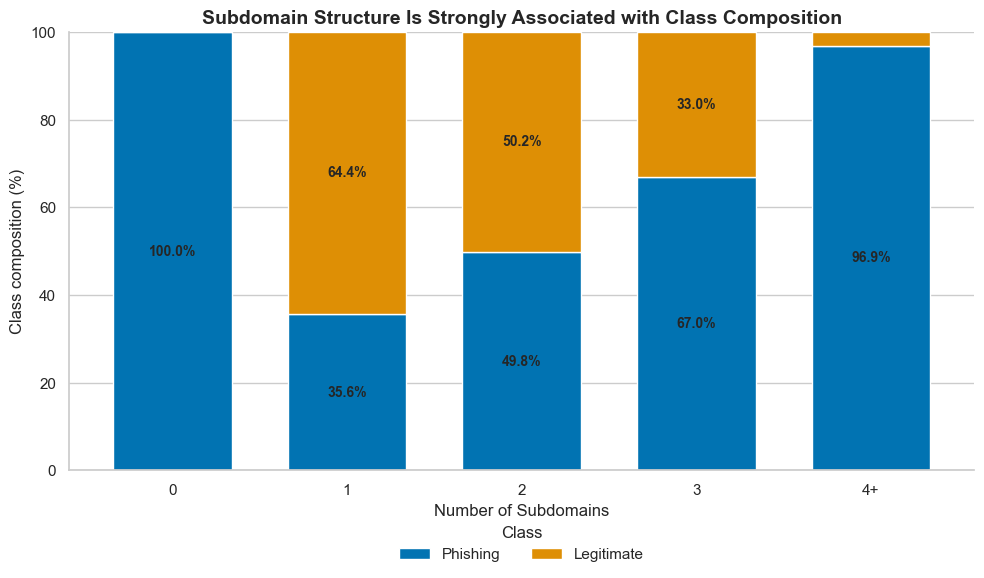

In [34]:
subdomain_final_group = df["NoOfSubDomain"].apply(
    lambda x: "4+" if x >= 4 else str(int(x))
)

subdomain_final = pd.crosstab(
    subdomain_final_group,
    df["label"].map({0: "Phishing", 1: "Legitimate"}),
    normalize="index"
).mul(100)

order = ["0", "1", "2", "3", "4+"]
subdomain_final = subdomain_final.reindex(
    [x for x in order if x in subdomain_final.index]
)

colors = sns.color_palette("colorblind", 2)

ax = subdomain_final[["Phishing", "Legitimate"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=colors,
    width=0.68
)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%" if bar.get_height() >= 5 else ""
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=10,
        weight="bold"
    )

ax.set_ylim(0, 100)
ax.set_xlabel("Number of Subdomains")
ax.set_ylabel("Class composition (%)")
ax.set_title(
    "Subdomain Structure Is Strongly Associated with Class Composition",
    fontsize=14,
    weight="bold"
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(
    title="Class",
    ncol=2,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.24),
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()


# Digest

In this section, you should briefly summarize the main findings of your project. Additionally, provide a critical reflection on your work and the effort invested throughout the module. Highlight the aspects you believe were handled successfully, as well as those that, in hindsight, you would approach differently.

While this digest must contain at least 2,500 characters, it is intended solely for self-reflection purposes and will not be considered in the formal evaluation of your work.

The exploratory analysis of the PhiUSIIL Phishing URL Dataset revealed several clear differences between phishing and legitimate webpages, while also showing why individual indicators should be interpreted carefully. After removing the `FILENAME` identifier, the dataset contained 235,795 instances and 54 predictive features. The class distribution was reasonably balanced, with approximately 42.81% phishing and 57.19% legitimate instances, which allowed the exploratory comparisons to be made without a severe class-imbalance problem.

One of the strongest findings was related to URL structure. Phishing URLs were generally longer and much more variable than legitimate URLs. The median URL length was 34 characters for phishing observations and 26 for legitimate observations, while the standard deviation was also substantially larger for phishing URLs. The `URLSimilarityIndex` produced an even clearer separation: all legitimate observations had a value of 100, whereas phishing observations had a median of 51.42 and a mean of 49.62. This feature therefore appears highly informative in this dataset. At the same time, such an extreme separation deserves caution in later stages of the project. Before relying heavily on this variable in a predictive model, it will be important to verify whether this behavior represents a generalizable phishing characteristic or whether it is partially related to how the dataset or feature itself was constructed.

HTTPS usage also produced an important result. Every observation without HTTPS was classified as phishing, but HTTPS did not guarantee legitimacy: 26.93% of HTTPS-enabled webpages were still phishing. This was a useful reminder that a technically secure connection and a trustworthy website are different concepts. Another informative result involved the number of subdomains. Among URLs with at least one subdomain, the phishing proportion increased from 35.62% for one subdomain to 96.90% for four or more. However, the zero-subdomain category contained 100% phishing observations. This was one of the most interesting non-obvious behaviors found during the analysis because it showed that the relationship is not simply “more subdomains means more phishing.” The structure of the URL appears to matter in a more complex way.

The joint analysis of `DomainTitleMatchScore` and `URLTitleMatchScore` also showed substantial class differences. Legitimate webpages had a median of 100 for both scores, while phishing webpages had a median of 0. Their mean values were also much lower for phishing pages. Considering the two scores together reinforced the idea that consistency between a page title, its domain, and its URL is associated with legitimacy in this dataset.

A significant part of the work involved improving how highly skewed and zero-inflated variables were visualized. Several features contained extreme right tails, very large maximum values, or large concentrations at zero. Initially, simply restricting plots to the 99th percentile made the central distributions easier to see, but it also hid part of the data and made the choice of cutoff arbitrary. A better approach was adopted: logarithmic transformations were used only for visualization when necessary, and zero-inflated variables were sometimes separated into zero-versus-positive views. This preserved every observation while making the plots more interpretable. The choice of visualization was also adapted to the variable type instead of applying the same histogram to every feature. Count plots, histograms, KDEs, violin plots, normalized stacked bars, and two-dimensional heatmaps were used according to the analytical question.

One aspect that was handled successfully was the progressive refinement of the visualizations. The first plots were useful for identifying distributions, but several were visually weak because extreme values or dominant categories compressed the rest of the information. Revisiting these plots led to clearer visual choices and better explanations of what each figure was intended to communicate. The three final visualizations were therefore designed for an audience that does not already know the dataset: they emphasize the main message, use percentages where class sizes differ, keep the color palette consistent, and avoid unnecessary visual complexity.

In hindsight, the exploratory process could have been more systematic from the beginning. Before choosing a plot, each variable could first have been classified as continuous, discrete, binary, bounded, zero-inflated, or heavy-tailed. This would have reduced the number of revisions needed later. It would also have been useful to define the main analytical questions before creating the first visualizations, rather than initially focusing mostly on producing the required number of univariate plots. The later multivariate stage showed that the most valuable analyses are those that connect a feature directly to the phishing-detection problem and test a clear hypothesis.

Overall, the checkpoint provided a much better understanding of the dataset before machine learning is applied. The analysis identified several potentially informative features, but it also highlighted the need to avoid interpreting strong associations as causal relationships or assuming that a feature that separates the current dataset perfectly will necessarily generalize to real-world data. The next stage should therefore preserve this critical perspective when preprocessing the features, splitting the data, training models, and validating whether the observed patterns remain useful outside the exploratory analysis.


# Checkpoint Submission *(**Ignore this component in the final submission**)*

1. Save this report as a Jupyter Notebook (`.ipynb`), ensuring that all code cells are executed and their outputs are visible in the exported notebook;
2. Export a copy of the report as a PDF file (`.pdf`), ensuring that all code cells are executed and their outputs are visible in the exported document. If the generated PDF has formatting issues, include it in the submission anyway;
4. Copy the dataset (if smaller than 10 MB);
5. Compress all the files (the Jupyter Notebook, PDF, and dataset) into a single ZIP archive named `EquipeXX.zip`, replacing XX with your team number;
6. Upload the ZIP file to Canvas.

# Machine Learning (**post-checkpoint!**)

In this section, you must create at least **3 machine learning models** for the task at hand. Depending on the problem's nature, you must select from classification, regression, or clustering models.
It is also important that you:
* Select **an appropriate validation protocol**, providing a rationale for why it is appropriate for this specific task;
* Choose **a suitable set of evaluation metrics**, providing an explanation for each and describing how it contributes to evaluating the model's performance in the context of this specific task.

In [35]:
# use as many cells as needed

# Final Steps (Submission)


1. Run all cells in the notebook and make sure every cell is executed successfully, with all outputs visible;
2. Save this report as a Jupyter Notebook (`.ipynb`);
3. Export a copy of the report as a PDF file (`.pdf`), ensuring that all code cells are executed and their outputs are visible in the exported document. If the generated PDF has formatting issues, include it in the submission anyway;
4. Copy the dataset (if smaller than 10 MB);
5. Compress all the files (the Jupyter Notebook, PDF, and dataset) into a single ZIP archive (`EquipeXX.zip`);
6. Upload the ZIP file to Canvas.